#Exercícios para entregar 5 (Parte 2)

###Aluno: Katlyn Ribeiro Almeida           
###Nusp:14586070

In [27]:
#acredito que separar os imports antes do codigo auxilia na melhor compreenção do mesmo
import numpy as np
import statistics
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, ClassifierMixin


In [2]:
#serao utilizados as bases pegando direto do drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1 - Realize a classificação da base winequality-red usando validação cruzada e o método grid_search para escolher os melhores hiperparâmetros do modelo árvore de decisão e knn

In [30]:
#codigo referente ao exercicio 1

#caminho para a base winequality-red pelo drive-------------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/winequality-red.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

#divisão do treino e do teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

#normalização
scaler = StandardScaler()
X_treino = scaler.fit_transform(X_treino)
X_teste = scaler.transform(X_teste)


#Grid Search para Árvore de Decisão----------------------------------------------------------------
def grid_search_arvoreD(X_treino, y_treino):
  #teste
  param_grid_tree = {
      'criterion': ['gini', 'entropy'],
      'max_depth': [None, 5, 10, 15, 20],
      'min_samples_split': [2, 5, 10]
  }
  grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='accuracy')
  grid_tree.fit(X_treino, y_treino)

  return grid_tree

#Grid Search para KNN--------------------------------------------------------------------------------------------------
def grid_search_knn(X_treino, y_treino):
  #teste
  param_grid_knn = {
      'n_neighbors': [3, 5, 7, 9, 11, 13],
      'weights': ['uniform', 'distance'],
      'metric': ['euclidean', 'manhattan']
  }

  grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
  grid_knn.fit(X_treino, y_treino)

  return grid_knn

gS_arvore = grid_search_arvoreD(X_treino, y_treino)
print(f"os melhores parâmetros da arvore de decisão: {gS_arvore.best_params_}")
print(f"a melhor acurácia: {gS_arvore.best_score_:.4f}")
print("==============================================================")

grid_knn = grid_search_knn(X_treino, y_treino)
print(f"os melhores parâmetros de KNN: {grid_knn.best_params_}")
print(f"a melhor acurácia: {grid_knn.best_score_:.4f}")
print("==============================================================")

os melhores parâmetros da arvore de decisão: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
a melhor acurácia: 0.6036
os melhores parâmetros de KNN: {'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'distance'}
a melhor acurácia: 0.6654


2 - Verifique se o número de folds, usado na validação cruzada, influencia na classificação da base winequality-red. Use o classificador Naive Bayes.


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=15.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=20.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=25.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=30.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 10 members, which is less than n_splits=35.
  warnings.warn(


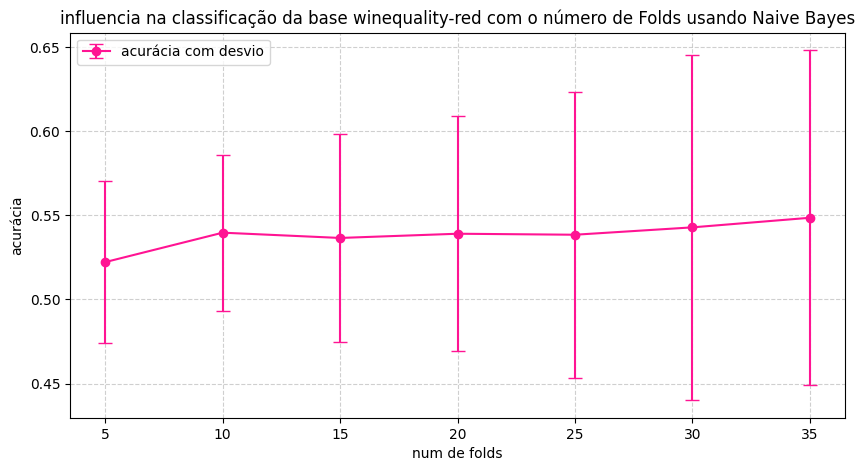

In [29]:
#codigo referente ao exercicio 2

#caminho para a base winequality-red pelo drive-------------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/winequality-red.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#testando para diferentes valores de folds
folds = [5, 10, 15, 20, 25, 30, 35]
resultados_medios = []
desvios_padrao = []

nb = GaussianNB()

for k in folds:
    #validação cruzada para cada k
    scores = cross_val_score(nb, X_scaled, y, cv=k)
    resultados_medios.append(scores.mean())
    desvios_padrao.append(scores.std())


#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.errorbar(folds, resultados_medios, yerr=desvios_padrao, fmt='-o', capsize=5, color='deeppink', label='acurácia com desvio')
plt.title('influencia na classificação da base winequality-red com o número de Folds usando Naive Bayes')
plt.xlabel('num de folds')
plt.ylabel('acurácia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


3 - Use validação cruzada para escolher o melhor valor de h no classificador bayesiano não paramétrico. Use a base Vehicle.

/tmp/ipykernel_7631/1799258531.py:25: RuntimeWarning: invalid value encountered in divide
  return result / result.sum(axis=1, keepdims=True)
/tmp/ipykernel_7631/1799258531.py:25: RuntimeWarning: invalid value encountered in divide
  return result / result.sum(axis=1, keepdims=True)
/tmp/ipykernel_7631/1799258531.py:25: RuntimeWarning: invalid value encountered in divide
  return result / result.sum(axis=1, keepdims=True)


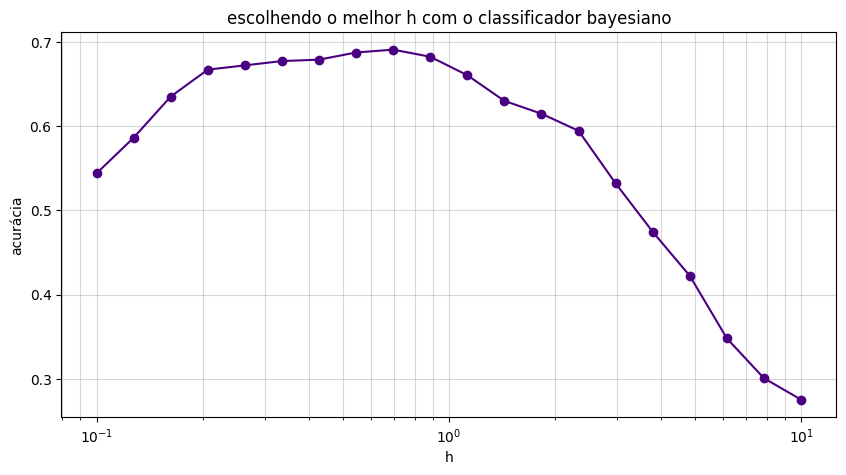

In [34]:
#codigo referente ao exercicio 3

#classificador Bayesiano não paramétrico----------------------------------------------------------------
class KDEClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, bandwidth=1.0, kernel='gaussian'):
        self.bandwidth = bandwidth
        self.kernel = kernel

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models_ = []
        for c in self.classes_:
            # Treina um estimador de densidade para cada classe
            kde = KernelDensity(bandwidth=self.bandwidth, kernel=self.kernel)
            kde.fit(X[y == c])
            self.models_.append(kde)
        # Calcula a probabilidade a priori de cada classe
        self.logpriors_ = [np.log(np.sum(y == c) / len(y)) for c in self.classes_]
        return self

    def predict_proba(self, X):
        # Calcula a verossimilhança P(X|classe) + log(prior)
        logprobs = np.array([model.score_samples(X) for model in self.models_]).T
        result = np.exp(logprobs + self.logpriors_)
        return result / result.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


#caminho para a base vehicle pelo drive-------------------------------------------------
file_path= "/content/drive/MyDrive/Aprendizado_de_maquina_exercicios/Vehicle.csv"
data = pd.read_csv(file_path)
#remove as linhas vazias
data = data.dropna()

#dados
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

#normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_treino, X_teste, y_treino, y_teste = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

#aqui busca o melhor valor de h pela validação cruzada
h_valores = np.logspace(-1, 1, 20)
param_grid = {'bandwidth': h_valores}

grade = GridSearchCV(KDEClassifier(), param_grid, cv=5)
grade.fit(X_treino, y_treino)


#plotando o grafico---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.semilogx(h_valores, grade.cv_results_['mean_test_score'], marker='o', color='indigo')
plt.title('escolhendo o melhor h com o classificador bayesiano')
plt.xlabel('h')
plt.ylabel('acurácia')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()